In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('synthetic_fraud_dataset.csv')

print('Загружено строк:', len(df))
print(df.head())

print("Распределение целевой переменной: ")
print(df['Fraud_Label'].value_counts())
print("Нормализованные доли: ")
print(df['Fraud_Label'].value_counts(normalize=True))

Загружено строк: 50000
  Transaction_ID    User_ID  Transaction_Amount Transaction_Type  \
0      TXN_33553  USER_1834               39.79              POS   
1       TXN_9427  USER_7875                1.19    Bank Transfer   
2        TXN_199  USER_2734               28.96           Online   
3      TXN_12447  USER_2617              254.32   ATM Withdrawal   
4      TXN_39489  USER_2014               31.28              POS   

             Timestamp  Account_Balance Device_Type  Location  \
0  2023-08-14 19:30:00         93213.17      Laptop    Sydney   
1  2023-06-07 04:01:00         75725.25      Mobile  New York   
2  2023-06-20 15:25:00          1588.96      Tablet    Mumbai   
3  2023-12-07 00:31:00         76807.20      Tablet  New York   
4  2023-11-11 23:44:00         92354.66      Mobile    Mumbai   

  Merchant_Category  IP_Address_Flag  ...  Daily_Transaction_Count  \
0            Travel                0  ...                        7   
1          Clothing                0 

In [58]:
print('Пропуски по колонкам:\n', df.isnull().sum())
print(f'\n Дубликаты строк: {df.duplicated().sum()}')

Пропуски по колонкам:
 Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

 Дубликаты строк: 0


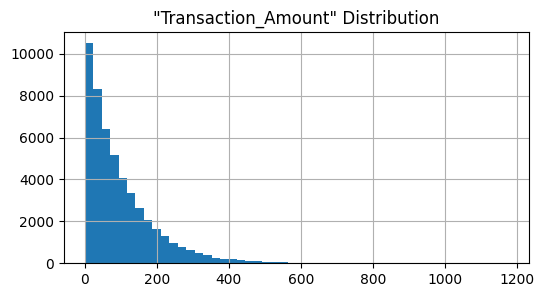

In [59]:
# Обработка выбросов
df['Transaction_Amount'].hist(bins=50, figsize=(6, 3))
plt.title('"Transaction_Amount" Distribution')
plt.show()

# Лог-трансформация
df['Transaction_Amount_log'] = np.log1p(df['Transaction_Amount'])

In [60]:
# Типы данных и разложение Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['is_night'] = df['hour'].apply(lambda x: 1 if (x<6 or x>22) else 0)

print('Типы данных:\n', df.dtypes)

Типы данных:
 Transaction_ID                          object
User_ID                                 object
Transaction_Amount                     float64
Transaction_Type                        object
Timestamp                       datetime64[ns]
Account_Balance                        float64
Device_Type                             object
Location                                object
Merchant_Category                       object
IP_Address_Flag                          int64
Previous_Fraudulent_Activity             int64
Daily_Transaction_Count                  int64
Avg_Transaction_Amount_7d              float64
Failed_Transaction_Count_7d              int64
Card_Type                               object
Card_Age                                 int64
Transaction_Distance                   float64
Authentication_Method                   object
Risk_Score                             float64
Is_Weekend                               int64
Fraud_Label                              int64

In [61]:
# Кодирование категориальных признаков

# Аутентификация
auth_order = {'Password': 1, 'PIN': 2, 'OTP': 3, 'Biometric': 4}
df['Auth_Level'] = df['Authentication_Method'].map(auth_order)

# Merchant_Category
cat_freq = df['Merchant_Category'].value_counts(normalize=True)
rare_cats = cat_freq[cat_freq < 0.5].index
df['Merchant_Group'] = df['Merchant_Category'].apply(lambda x: 'Other' if x in rare_cats else x)
df_enc = pd.get_dummies(df, columns=['Merchant_Group', 'Location'], drop_first=True, dtype=int)

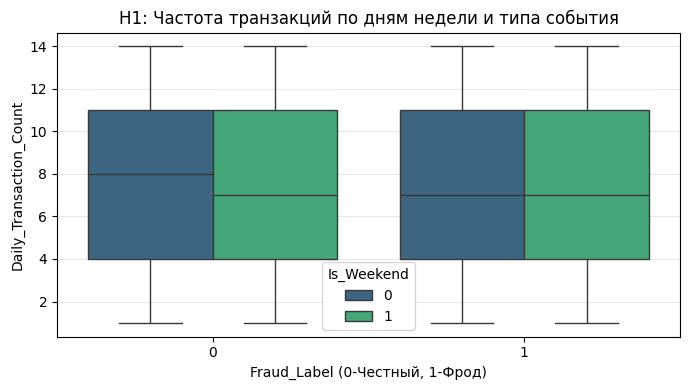

In [62]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Fraud_Label', y='Daily_Transaction_Count', hue='Is_Weekend',
            data=df, palette='viridis')
plt.title('H1: Частота транзакций по дням недели и типа события')
plt.ylabel('Daily_Transaction_Count')
plt.xlabel('Fraud_Label (0-Честный, 1-Фрод)')
plt.legend(title='Is_Weekend')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10071/2613916933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IP_Address_Flag', y='Fraud_Rate', data=ip_fraud_rate, palette='coolwarm')


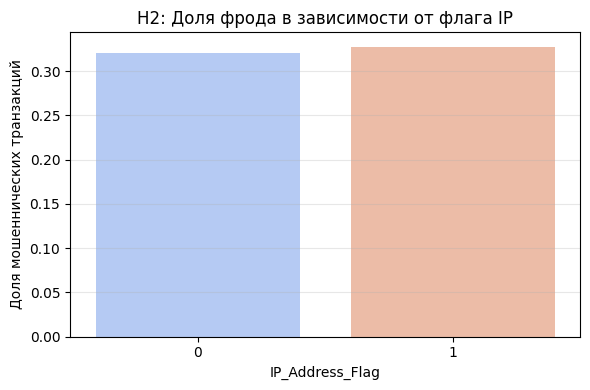

In [63]:
# Для упрощения: посмотрим долю фрода в зависимости от флага IP

ip_fraud_rate = df.groupby('IP_Address_Flag')['Fraud_Label'].mean().reset_index()
ip_fraud_rate.rename(columns={'Fraud_Label': 'Fraud_Rate'}, inplace=True)

plt.figure(figsize=(6, 4))
sns.barplot(x='IP_Address_Flag', y='Fraud_Rate', data=ip_fraud_rate, palette='coolwarm')
plt.title('H2: Доля фрода в зависимости от флага IP')
plt.ylabel('Доля мошеннических транзакций')
plt.xlabel('IP_Address_Flag')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

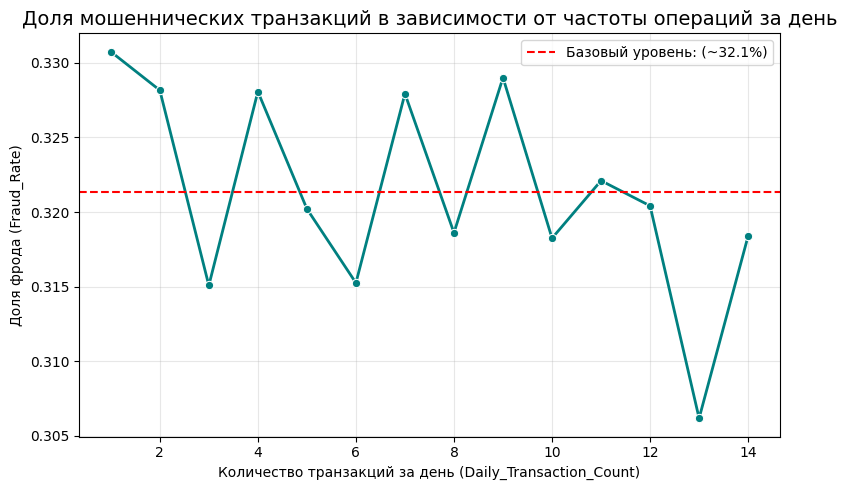

In [64]:
# 1. Группируем по уровню частоты и считаем долю фрода
fraud_by_count = df.groupby('Daily_Transaction_Count')['Fraud_Label'].mean().reset_index()
fraud_by_count.rename(columns={'Fraud_Label': 'Fraud_Rate'}, inplace=True)

# 2. Строим график
plt.figure(figsize=(8, 5))
sns.lineplot(data=fraud_by_count, x='Daily_Transaction_Count', y='Fraud_Rate', marker='o',
             linewidth=2, color='teal')

# 3. Добавляем базовую линию (общая доля фрода в датасете)
overall_fraud_rate = df['Fraud_Label'].mean()
plt.axhline(y=overall_fraud_rate, color='red', linestyle='--', linewidth=1.5,
            label=f'Базовый уровень: (~{overall_fraud_rate:.1%})')

plt.title('Доля мошеннических транзакций в зависимости от частоты операций за день', fontsize=14)
plt.xlabel('Количество транзакций за день (Daily_Transaction_Count)')
plt.ylabel('Доля фрода (Fraud_Rate)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
# Сравниваем распределение частоты операций (Daily_Transaction_Count)
# между честными (0) и фродом (1)

honest = df.loc[df['Fraud_Label'] == 0, 'Daily_Transaction_Count']
fraud = df.loc[df['Fraud_Label'] == 1, 'Daily_Transaction_Count']
# Вычисляем KS-статистику и p-value
ks_stat, p_ks = stats.ks_2samp(honest, fraud)
print(f'KS-статистика: (Daily_Transaction_Count): p-value = {p_ks:.4f}, D = {ks_stat:.4f}')

# Также для сумм за 7 дней
amount_honest = df.loc[df['Fraud_Label'] == 0, 'Avg_Transaction_Amount_7d']
amount_fraud = df.loc[df['Fraud_Label'] == 1, 'Avg_Transaction_Amount_7d']
# Вычисляем KS-статистику и p-value
ks_stat_2, p_ks_2 = stats.ks_2samp(amount_honest, amount_fraud)
print(f'KS-статистика: (Avg_Transaction_Amount_7d): p-value = {p_ks_2:.4f}, D = {ks_stat_2:.4f}')

# Cвязь между количеством сбоев за 7 дней и фродом
corr_f, p_f = stats.pearsonr(df['Failed_Transaction_Count_7d'], df['Fraud_Label'])
print(f'P-статистика: (Failed_Transaction_Count_7d): p-value = {p_f:.4f}, corr = {corr_f:.4f}')

KS-статистика: (Daily_Transaction_Count): p-value = 0.6668, D = 0.0069
KS-статистика: (Avg_Transaction_Amount_7d): p-value = 0.7692, D = 0.0063
P-статистика: (Failed_Transaction_Count_7d): p-value = 0.0000, corr = 0.5099
